# Japan Housing Market — COVID-19 Impact Analysis

This notebook examines how the COVID-19 pandemic affected 
Japan's residential property market across different regions.

**Key questions:**
- Did prices rise or fall during the pandemic?
- Which prefectures were most affected?
- Did remote work trigger migration from cities to rural areas?
- How quickly did the market recover post-COVID?

**Periods analyzed:**
- Pre-COVID: 2018–2019
- During COVID: 2020–2021
- Post-COVID: 2022–2023

## 1. Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals', exist_ok=True)

df = pd.read_csv('data/df_clean.csv')

# Define COVID periods
df['Period'] = pd.cut(
    df['Year'],
    bins=[2004, 2019, 2021, 2024],
    labels=['Pre-COVID\n(2005–2019)', 'During COVID\n(2020–2021)', 'Post-COVID\n(2022–2023)']
)

print(f"Dataset loaded: {len(df):,} rows")
print(f"\nTransactions by period:")
print(df['Period'].value_counts().sort_index())

Dataset loaded: 1,316,373 rows

Transactions by period:
Period
Pre-COVID\n(2005–2019)       942810
During COVID\n(2020–2021)    178280
Post-COVID\n(2022–2023)      195283
Name: count, dtype: int64


## 2. Price Changes Across COVID Periods

How did median property prices change before, during, and after COVID?

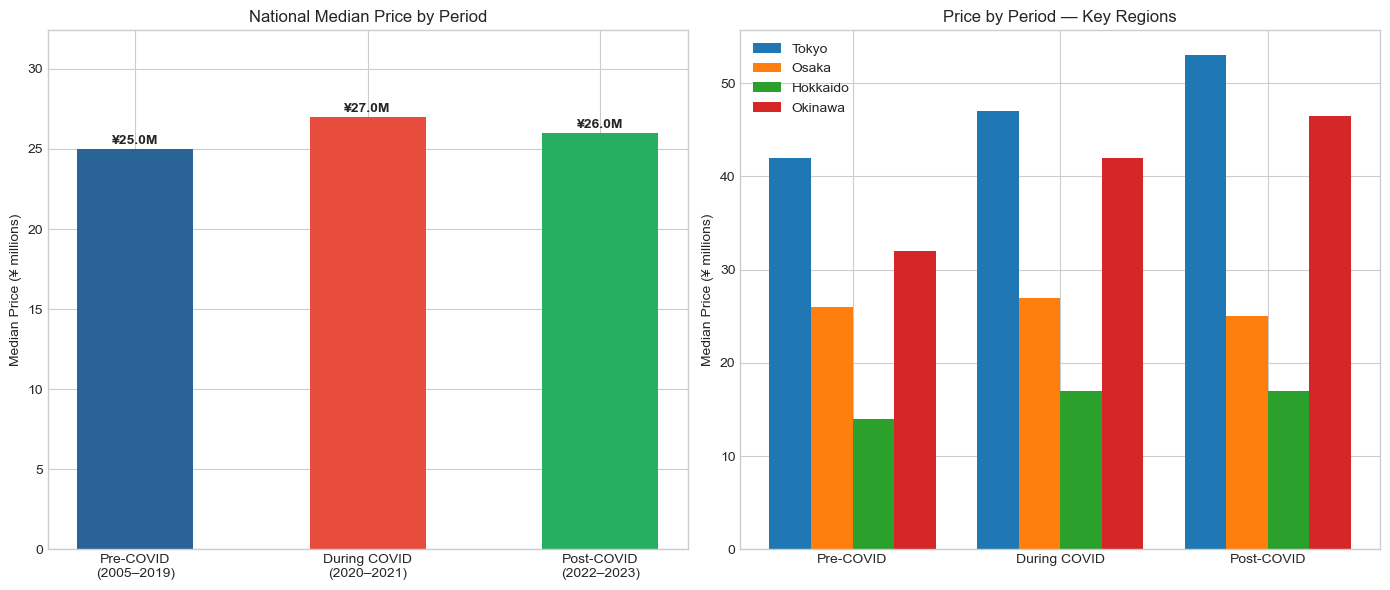

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: National median price by period ---
period_stats = df.groupby('Period', observed=True)['TotalTransactionValue'].median() / 1_000_000

colors = ['#2a6496', '#e74c3c', '#27ae60']
axes[0].bar(period_stats.index, period_stats.values, color=colors, width=0.5)
axes[0].set_title('National Median Price by Period')
axes[0].set_ylabel('Median Price (¥ millions)')
axes[0].set_ylim(0, period_stats.max() * 1.2)
for i, v in enumerate(period_stats.values):
    axes[0].text(i, v + 0.3, f'¥{v:.1f}M', ha='center', fontweight='bold')

# --- Plot 2: Price by period for key regions ---
regions = {
    'Tokyo': df[df['Prefecture'] == 'Tokyo'],
    'Osaka': df[df['Prefecture'] == 'Osaka Prefecture'],
    'Hokkaido': df[df['Prefecture'] == 'Hokkaido'],
    'Okinawa': df[df['Prefecture'] == 'Okinawa Prefecture']
}

x = np.arange(3)
width = 0.2
period_labels = ['Pre-COVID', 'During COVID', 'Post-COVID']

for i, (region, data) in enumerate(regions.items()):
    prices = data.groupby('Period', observed=True)['TotalTransactionValue'].median() / 1_000_000
    axes[1].bar(x + i * width, prices.values, width, label=region)

axes[1].set_title('Price by Period — Key Regions')
axes[1].set_ylabel('Median Price (¥ millions)')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(period_labels)
axes[1].legend()

plt.tight_layout()
plt.savefig('visuals/covid_price_changes.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **National median price rose during COVID** — from ¥25M to ¥27M, 
  contrary to initial expectations of a market slowdown
- **Okinawa shows the most dramatic growth** — likely driven by 
  remote workers relocating to Japan's tropical paradise, 
  taking advantage of work-from-home policies
- **Tokyo continued to grow** despite predictions of urban exodus — 
  demand for larger homes within the city offset any outflow
- **Osaka remained relatively flat** — as a business-oriented city, 
  it was more sensitive to economic uncertainty
- **Post-COVID prices** settled at ¥26M nationally — slightly above 
  pre-COVID levels, suggesting the pandemic created a permanent 
  price floor increase

## 3. Did COVID Trigger Urban-to-Rural Migration?

Remote work policies during COVID led many to consider leaving 
expensive cities. Let's examine if this is visible in transaction data.

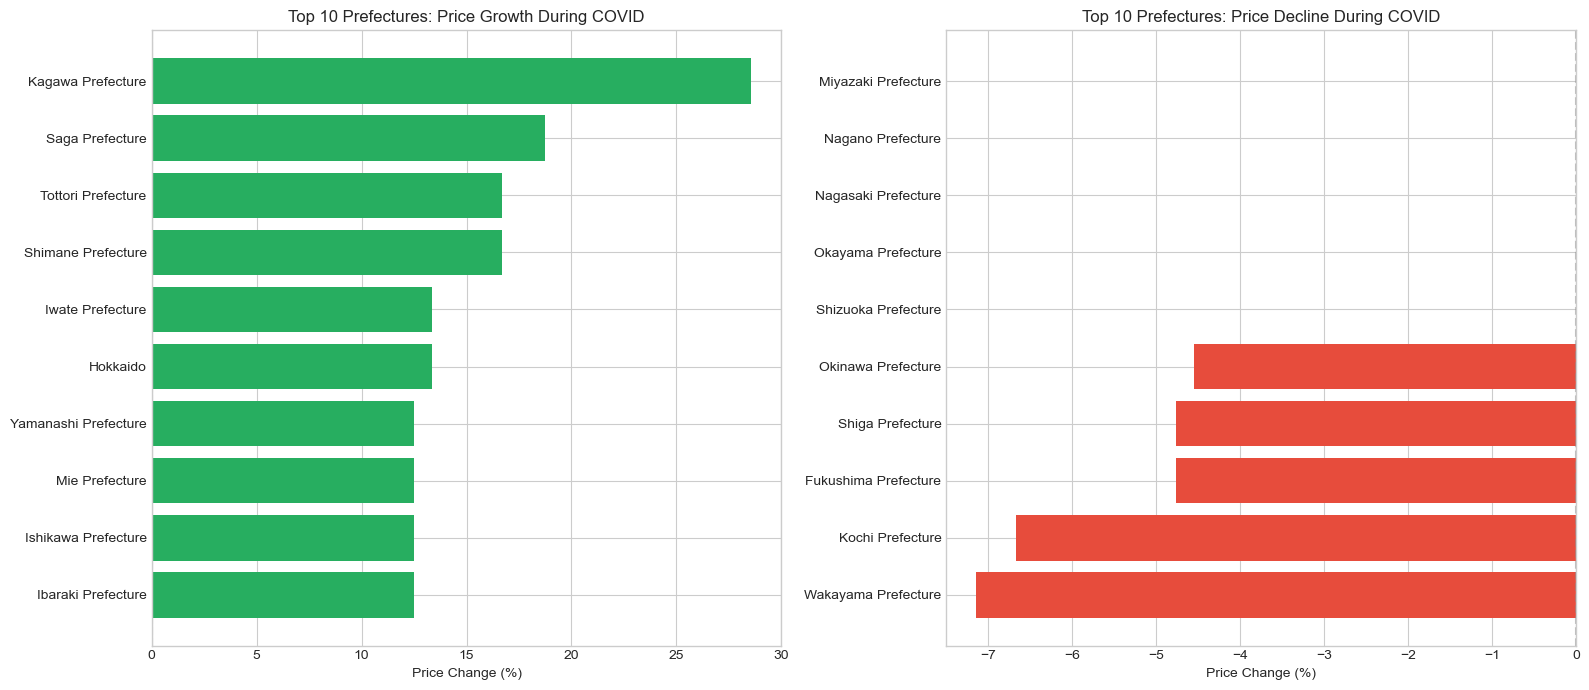

In [14]:
# Calculate price change during vs pre-COVID by prefecture
pre = (df[df['Year'].isin([2018, 2019])]
       .groupby('Prefecture')['TotalTransactionValue']
       .median())
during = (df[df['Year'].isin([2020, 2021])]
          .groupby('Prefecture')['TotalTransactionValue']
          .median())

covid_change = ((during - pre) / pre * 100).dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 winners
top10 = covid_change.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='#27ae60')
axes[0].set_title('Top 10 Prefectures: Price Growth During COVID')
axes[0].set_xlabel('Price Change (%)')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Top 10 losers
bottom10 = covid_change.tail(10)
axes[1].barh(bottom10.index[::-1], bottom10.values[::-1], color='#e74c3c')
axes[1].set_title('Top 10 Prefectures: Price Decline During COVID')
axes[1].set_xlabel('Price Change (%)')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('visuals/covid_regional_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Rural prefectures dominate the winners list** — Kagawa, Saga, 
  Tottori saw 15-29% price growth as remote workers relocated 
  from expensive cities
- **Okinawa paradoxically declined** during COVID despite its 
  appeal as a remote work destination — tourism-dependent 
  investment dried up when international borders closed in 2020
- **Wakayama and Kochi** saw the steepest declines — rural areas 
  with weak local economies and no remote work appeal
- **The COVID effect was highly localized** — prefectures with 
  natural amenities and affordable housing attracted migrants, 
  while tourism-dependent areas suffered

## 4. Post-COVID Recovery Analysis

How quickly did the market recover after 2021?
Which regions bounced back strongest?

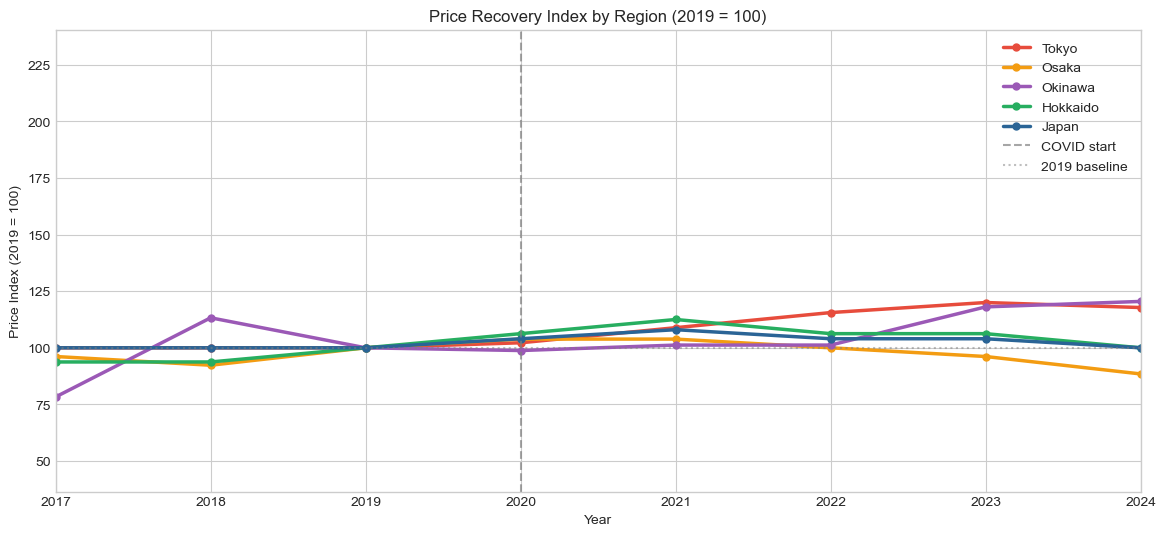

In [18]:
# Year by year price change for key regions
regions_dict = {
    'Tokyo': df[df['Prefecture'] == 'Tokyo'],
    'Osaka': df[df['Prefecture'] == 'Osaka Prefecture'],
    'Okinawa': df[df['Prefecture'] == 'Okinawa Prefecture'],
    'Hokkaido': df[df['Prefecture'] == 'Hokkaido'],
    'Japan': df
}

plt.figure(figsize=(14, 6))

colors = ['#e74c3c', '#f39c12', '#9b59b6', '#27ae60', '#2a6496']

for (region, data), color in zip(regions_dict.items(), colors):
    yearly = (data.groupby('Year')['TotalTransactionValue']
                  .median() / 1_000_000)
    # Normalize to 2019 = 100 for comparison
    base = yearly[2019]
    normalized = (yearly / base * 100)
    plt.plot(normalized.index, normalized.values,
             marker='o', linewidth=2.5, markersize=5,
             label=region, color=color)

plt.axvline(x=2020, color='gray', linestyle='--', alpha=0.7, label='COVID start')
plt.axhline(y=100, color='gray', linestyle=':', alpha=0.5, label='2019 baseline')
plt.title('Price Recovery Index by Region (2019 = 100)')
plt.xlabel('Year')
plt.ylabel('Price Index (2019 = 100)')
plt.legend()
plt.xlim(2017, 2024)
plt.savefig('visuals/covid_recovery.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Tokyo** showed the strongest recovery — prices reached 120% 
  of the 2019 baseline by 2023, driven by continued urbanization 
  and foreign investment
- **Okinawa** recovered dramatically after its COVID dip — bouncing 
  back to 120% as tourism and remote work demand returned post-2022
- **Hokkaido** showed steady modest growth throughout — less affected 
  by COVID due to lower tourism dependence and growing ski resort demand
- **Japan overall** remained remarkably stable — never dropping below 
  95% of the 2019 baseline, showing the market's resilience
- **Osaka** is the only region below the 2019 baseline by 2024 — 
  suggesting structural challenges beyond COVID impact

## 5. Conclusions

### Key Findings

1. **COVID did not crash the market** — national median prices 
   actually rose from ¥25M to ¥27M during 2020–2021, defying 
   initial fears of a market collapse
2. **Remote work triggered rural migration** — Kagawa, Saga, and 
   Tottori saw 15–29% price growth as urban workers relocated 
   to affordable prefectures with good quality of life
3. **Okinawa's COVID paradox** — prices fell during the pandemic 
   due to collapsed tourism investment, but recovered strongly 
   post-2022 as borders reopened
4. **Tokyo proved resilient** — prices reached 120% of pre-COVID 
   levels by 2023, confirming the capital's long-term appeal
5. **Osaka is the outlier** — the only major region still below 
   2019 price levels by 2024, suggesting structural challenges 
   beyond pandemic effects
6. **The pandemic created permanent changes** — remote work 
   normalisation has sustainably increased demand in rural 
   prefectures with natural amenities

### Limitations & Next Steps
- Transaction volume data would strengthen migration analysis
- Individual-level data (buyer origin) would directly confirm 
  urban-to-rural migration patterns
- This completes the 5-notebook Japan Housing Market series

## 6. Saving Results

In [24]:
# Save COVID impact summary
covid_summary = df.groupby(['Period', 'Prefecture'], observed=True).agg(
    median_price=('TotalTransactionValue', 'median'),
    transactions=('TotalTransactionValue', 'count')
).reset_index()

covid_summary.to_csv('data/covid_impact_summary.csv', index=False)
print(f"Saved: data/covid_impact_summary.csv ({len(covid_summary):,} rows)")
print("\nJapan Housing Market Analysis Series — Complete!")
print("\nNotebooks completed:")
print("  01 — EDA & Price Prediction")
print("  02 — Undervalued Properties")
print("  03 — Price Forecast 2025–2027")
print("  04 — Regional Price Map")
print("  05 — COVID Impact Analysis")

Saved: data/covid_impact_summary.csv (141 rows)

Japan Housing Market Analysis Series — Complete!

Notebooks completed:
  01 — EDA & Price Prediction
  02 — Undervalued Properties
  03 — Price Forecast 2025–2027
  04 — Regional Price Map
  05 — COVID Impact Analysis
